## 1. What this notebook computes

In the author's metric the three extra times $x_5, x_6, x_7$ DEFLATE: their lengths
carry the factor $e^{-a_4}\sin^{1/6}z$, and $a_4$ increases with the time $x_4$.
A wave that wiggles a fixed number of times per unit of the coordinate $x_5$
therefore wiggles more and more often per unit of PROPER length (length measured
with the metric): its frame momentum grows like $e^{a_4}$. This notebook uses the
deflating history of the Kohn-Sham record, $a_4 = A H x_4$ with $A = 1$ and
$H = m = 1$ (a PRESCRIBED background, not a solution of the $a_4$ equations), and

- draws the scale factors of 3-space (inflating) and of the extra times (deflating)
  and checks exactly that the volume factor $\sqrt{|g|} = \cos z$ does not change
  in time;
- computes the frame momenta of a wave with fixed wave numbers $q_1$ along $x_1$
  and $q_5$ along $x_5$, and the exact time $x_4^\ast$ at which $E^2 = m^2 +
  k_{(1)}^2 - k_{(5)}^2$ turns negative (the *onset*), checked against a numerical
  root search;
- shows that every wave with $q_5 \neq 0$ reaches the onset at a finite time: every
  wave along an extra time eventually grows (the Revision statement
  `extra_time_modes_grow`);
- follows one wave through the onset with the local-frame model (explained in
  section 4), solved with RK4 (fourth-order convergence checked), and compares its
  growth with the WKB formulas; the growth is faster than any exponential;
- checks that the Krein form stays constant while the ordinary size grows by a
  factor of about $10^{16}$.

It draws five teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 08b (The deflating extra times drive every extra-time wave into growth) is the
file `Revision/textbook/notebooks/08b_deflation_onset.ipynb` of the repository
Dirac_claude. Along the deflating history a4 = A H x4 of the Kohn-Sham record (A = 1, H =
m = 1, a prescribed background) it computes the scale factors and the frame momenta of a
wave with fixed wave numbers along x1 and x5, the exact time at which such a wave turns
from oscillation to growth, and shows that every wave along an extra time reaches this
onset; it then follows one wave through the onset with the local-frame model (RK4,
convergence of order 4) and compares the growth with the WKB formulas, checks the Krein
form, and draws five teaching plots. It needs a computer with Windows 11, macOS or Linux,
an internet connection for the installation, the program Git, and Python 3.12 or newer
(the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 08b_deflation_onset.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 08b_deflation_onset.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
08b_deflation_onset.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/08b.captions.json`
- `Revision/textbook/figures/08b_1_scale_factors.png`
- `Revision/textbook/figures/08b_2_frame_momenta.png`
- `Revision/textbook/figures/08b_3_onset_times.png`
- `Revision/textbook/figures/08b_4_growth_along_history.png`
- `Revision/textbook/figures/08b_5_rate_and_krein.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 08b_5_rate_and_krein.png exists
    ALL 25 CHECKS PASSED (notebook 08b)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/08b_deflation_onset.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- FileNotFoundError naming Revision/kohn_sham/results/parameters.json: the notebook reads
  this Revision record of the repository. Check that your copy of the repository contains
  the folder Revision/kohn_sham/results with the file parameters.json (clone the
  repository again if it does not) and that you opened the notebook from its folder
  Revision/textbook/notebooks.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 08b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 08b (The deflating extra times drive every extra-time wave into growth) is the
# file Revision/textbook/notebooks/08b_deflation_onset.ipynb of the repository
# Dirac_claude. Along the deflating history a4 = A H x4 of the Kohn-Sham record (A = 1, H
# = m = 1, a prescribed background) it computes the scale factors and the frame momenta
# of a wave with fixed wave numbers along x1 and x5, the exact time at which such a wave
# turns from oscillation to growth, and shows that every wave along an extra time reaches
# this onset; it then follows one wave through the onset with the local-frame model (RK4,
# convergence of order 4) and compares the growth with the WKB formulas, checks the Krein
# form, and draws five teaching plots. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 08b_deflation_onset.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 08b_deflation_onset.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 08b_deflation_onset.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/08b.captions.json
# - Revision/textbook/figures/08b_1_scale_factors.png
# - Revision/textbook/figures/08b_2_frame_momenta.png
# - Revision/textbook/figures/08b_3_onset_times.png
# - Revision/textbook/figures/08b_4_growth_along_history.png
# - Revision/textbook/figures/08b_5_rate_and_krein.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 08b_5_rate_and_krein.png exists
#     ALL 25 CHECKS PASSED (notebook 08b)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/08b_deflation_onset.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - FileNotFoundError naming Revision/kohn_sham/results/parameters.json: the notebook
#   reads this Revision record of the repository. Check that your copy of the repository
#   contains the folder Revision/kohn_sham/results with the file parameters.json (clone
#   the repository again if it does not) and that you opened the notebook from its folder
#   Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "08b"  # this notebook: chapter 08, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 08b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** (the author's names): $x_1, x_2, x_3$ ordinary space; $x_4$ the
  time; $x_5, x_6, x_7$ the three extra times (time-like, deflating); $x_8$ the
  hidden direction, $z = 6Hx_8$ between $0$ and $\pi/2$.
- **Hidden coordinate** $y = \ln(\sin z)/(6H)$: a second way to label the points of
  the hidden direction. $y = 0$ at $z = \pi/2$ (the end of the patch, where the
  Kohn-Sham record puts its brane) and $y \to -\infty$ at the tip $z \to 0$; the
  record cuts the tip at $y = -L$ with $L = 3$. In this coordinate
  $\sin^{1/6}z = e^{Hy}$.
- **Scale factor**: the factor by which a coordinate length must be multiplied to
  give the proper length; $e^{a_4}\sin^{1/6}z$ for $x_1, x_2, x_3$ and
  $e^{-a_4}\sin^{1/6}z$ for $x_5, x_6, x_7$. **Inflating** means growing,
  **deflating** shrinking.
- **History** $a_4(x_4)$: how $a_4$ changes with time. Here $a_4 = A H x_4$ with
  $A = 1$ (the canonical history of the Kohn-Sham record). It is PRESCRIBED: chosen,
  not solved for (the record shows that the Kohn-Sham states do not satisfy the
  source conditions of the $a_4$ equations).
- **Coordinate wave number** $q_a$ and **frame momentum** $k_{(a)} = q_a/f_a$, where
  $f_a$ is the scale factor: the wave $e^{iq_a x_a}$ has $q_a$ radians of phase per
  unit of coordinate length and $k_{(a)}$ radians per unit of proper length.
- **Mode matrix** $h = -im\gamma^{(4)} - \gamma^{(4)}\sum_a k_{(a)}\gamma^{(a)}$:
  with frozen coefficients a wave $u\,e^{-iEx_4}$ needs $hu = Eu$, and $h^2 = E^2$
  with $E^2 = m^2 + k_{(1)}^2 - k_{(5)}^2$ when only $k_{(1)}$ and $k_{(5)}$ are
  nonzero. **Onset**: the time at which $E^2$ turns negative.
- **Local-frame model**: the equation $i\,du/dx_4 = h(x_4)u$ in which the frame
  momenta change with $x_4$ as the history prescribes, while the hidden position is
  held fixed (section 4).
- **WKB approximation** (after Wentzel, Kramers and Brillouin): when the growth rate
  $\kappa$ changes slowly, the size grows like $e^{2W}$ with $W = \int\kappa\,dx_4$.
- **Krein form** $u^\dagger B u$ with the matrix $B = -iC\gamma^{(4)}$ of the record
  ($B^\dagger = B$, $B^2 = 1$); **Hilbert norm** $u^\dagger u$.
- **RK4**: the classical fourth-order Runge-Kutta method; *fourth order* means that
  halving the step divides the error by about $2^4 = 16$.

## 4. The physical and mathematical situation

In the hidden coordinate $y$ the author's metric reads
$ds^2 = e^{2Hy}\big(e^{2a_4}(dx_1^2 + dx_2^2 + dx_3^2) - e^{-2a_4}(dx_5^2 + dx_6^2
+ dx_7^2)\big) - dx_4^2 + dy^2$, because $\sin^{1/3}z = e^{2Hy}$ and $dy = \cot z\,
dx_8$. Its coefficients do not depend on $x_1, x_2, x_3, x_5, x_6, x_7$, so a wave
$e^{i(q_1x_1 + q_5x_5)}$ keeps its coordinate wave numbers $q_1, q_5$ exactly for
all times. Its frame momenta are, line by line:

1. $k_{(1)} = q_1/f_1 = q_1\,e^{-a_4}e^{-Hy}$ (the factor of $x_1$ is
   $f_1 = e^{a_4}e^{Hy}$);
2. $k_{(5)} = q_5/f_5 = q_5\,e^{a_4}e^{-Hy}$ (the factor of $x_5$ is
   $f_5 = e^{-a_4}e^{Hy}$);
3. with frozen coefficients $E^2 = m^2 + k_{(1)}^2 - k_{(5)}^2
   = m^2 + q_1^2e^{-2Hy}e^{-2a_4} - q_5^2e^{-2Hy}e^{2a_4}$.

As $a_4$ grows, the last term grows like $e^{2a_4}$ and the middle one decays like
$e^{-2a_4}$: $E^2$ must turn negative. With $X = e^{2a_4}$ and $w = e^{-Hy}$ the
onset $E^2 = 0$ is the quadratic equation $q_5^2w^2X^2 - m^2X - q_1^2w^2 = 0$, whose
positive root is $X^\ast = \big(m^2 + \sqrt{m^4 + 4q_1^2q_5^2w^4}\big)/(2q_5^2w^2)$;
the onset time is $x_4^\ast = \ln(X^\ast)/(2AH)$. For $q_1 = 0$ this is
$x_4^\ast = \big(Hy + \ln(m/q_5)\big)/(AH)$.

THE MODEL (labelled). The field also depends on $y$, and the factor $e^{-Hy}$ in
the frame momenta makes the exact equation couple neighbouring values of $y$. The
*local-frame model* holds the hidden position fixed (it freezes the coefficients
in $y$, the WKB statement of the Revision record), works in the variables
$\chi = \sin^{1/2}z\,\Psi$ (in which the term $3H\gamma^{(8)}$ of the diagonal
frame is absent exactly), takes no momentum along the hidden direction, and keeps
the exact time dependence of the frame momenta: $i\,du/dx_4 = h(x_4)u$ with
$h(x_4) = -im\gamma^{(4)} - \gamma^{(4)}\big(k_{(1)}(x_4)\gamma^{(1)} +
k_{(5)}(x_4)\gamma^{(5)}\big)$. Its solutions are not exact solutions of the field
equation; they show how a wave behaves near one hidden position. The position
enters only through $q_5e^{-Hy}$, so the runs below use $y = 0$.

Units: $H = m = 1$, as in the Kohn-Sham record; times in units of $1/m$, momenta
in units of $m$.

## 5. The deflating history of the Kohn-Sham record

The next cell first defines two helpers for the checks that reproduce a Revision
record. `record_says(report, name, ...)` opens the report (a JSON file with a list
of checks, each with a name, a verdict and a detail text) and is true when the
check `name` is there with the verdict pass and its detail text contains every
further piece of text given. `check_record(condition, title, report, name, ...)` is
the helper `check` for such a result: it passes only if the notebook's own
computation (`condition`) is right AND the record says the same. Then the cell
reads the parameters of the Kohn-Sham record, takes from it $H$, $m$, the history
constant $A$ and the tip cutoff $L$, prints how the record describes the history
and its status, and checks the values $A = H = m = 1$, $L = 3$.

In [2]:
import numpy as np  # arrays of numbers, matrices, linear algebra
import sympy as sp  # exact algebra with symbols

REPORTS = {}  # report file -> {check name: (verdict, detail)}, each read once


def record_says(report_file, check_name, *pieces):
    """True when the Revision report records the check check_name with the verdict
    pass and its detail text contains every given piece of text."""
    if report_file not in REPORTS:  # read the report the first time it is needed
        data = json.loads(repository_file(report_file).read_text(encoding="utf-8"))
        REPORTS[report_file] = {entry["name"]: (entry["verdict"].lower(),
                                                entry["detail"])
                                for entry in data["checks"]}
    verdict, detail = REPORTS[report_file][check_name]
    return verdict == "pass" and all(piece in detail for piece in pieces)


def check_record(condition, title, report_file, check_name, *pieces):
    """check() for a result that reproduces the Revision check check_name: it passes
    only if condition is true AND the report records check_name as passed, with
    every piece of text (values computed here) in its detail."""
    on_record = record_says(report_file, check_name, *pieces)
    check(condition and on_record, title,
          record=f"{report_file}, check {check_name}")


parameters = json.loads(repository_file(
    "Revision/kohn_sham/results/parameters.json").read_text(encoding="utf-8"))
H = parameters["physics"]["H"]  # the author's constant H
mass = parameters["physics"]["m"]  # the mass m
A = parameters["physics"]["historyA"]  # the history a4 = A H x4
L_tip = parameters["physics"]["L_tipCutoff"]  # the record cuts the tip at y = -L
say("history: " + parameters["theoryInputs"]["adiabaticityHistory"])
say("status: " + parameters["conventions"]["history"].split(". ")[0] + ".")
check(H == 1.0 and mass == 1.0 and A == 1.0 and L_tip == 3.0,
      "the canonical history: A = 1, H = 1, m = 1, tip cutoff L = 3",
      record="Revision/kohn_sham/results/parameters.json, physics.historyA, "
             "physics.H, physics.m, physics.L_tipCutoff")


def a4_of(x4):
    """The prescribed deflating history a4 = A H x4."""
    return A * H * x4

history: a4 = A H x4 (A = 1 canonical), a4' = A H; slices a4,0 = a4(x4); PRESCRIBED
    BACKGROUND (see historyStatus)
status: PRESCRIBED BACKGROUND: the history a4 = A H x4 is prescribed, not solved for.
PASS the canonical history: A = 1, H = 1, m = 1, tip cutoff L = 3
     reproduces Revision/kohn_sham/results/parameters.json, physics.historyA, physics.H,
    physics.m, physics.L_tipCutoff


## 6. The scale factors and the constant volume

The next cell first checks three exact statements with sympy: $dy/dx_8 = \cot z$
for $y = \ln(\sin z)/(6H)$; $e^{Hy} = \sin^{1/6}z$; and the product of the eight
scale factors, $(e^{a_4}\sin^{1/6}z)^3 \cdot 1 \cdot (e^{-a_4}\sin^{1/6}z)^3 \cdot
\cot z$, equals $\cos z$ for every $a_4$: the inflation of 3-space and the deflation
of the extra times compensate exactly. Then it draws the scale factors along the
history at two hidden positions.

PASS dy/dx8 = cot z
PASS e^(H y) = sin(z)^(1/6)
PASS sqrt|g| = product of the scale factors = cos z, for every a4
     reproduces Revision/theory/reports/python-field-theory.json, check
    sqrt_det_g_equals_cos_z


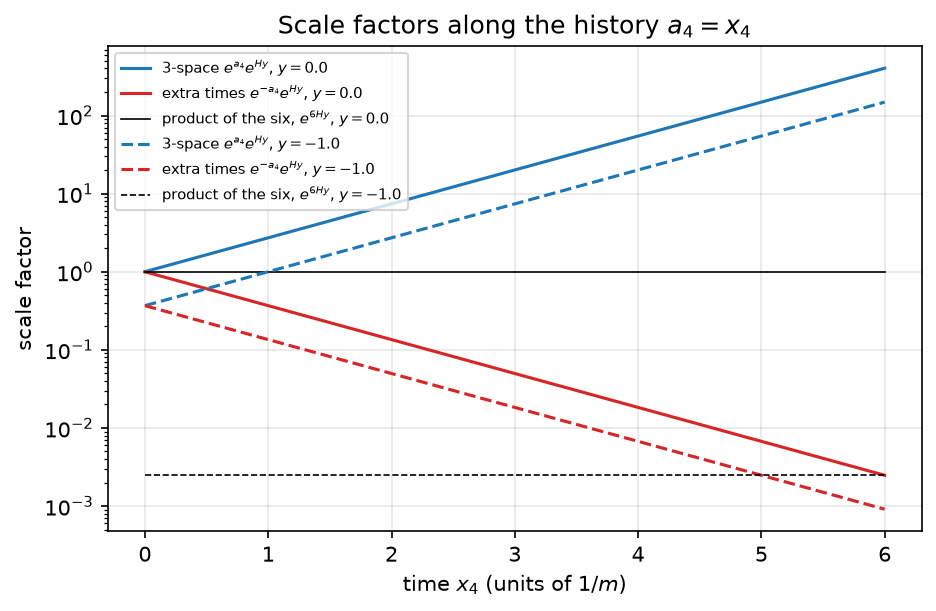

Figure 08b.1 saved as Revision/textbook/figures/08b_1_scale_factors.png


In [3]:
x8, H_symbol = sp.symbols("x8 H", positive=True)
a4_symbol = sp.Symbol("a4", real=True)
z = 6 * H_symbol * x8
y_of_x8 = sp.log(sp.sin(z)) / (6 * H_symbol)  # the hidden coordinate y
check(sp.simplify(sp.diff(y_of_x8, x8) - sp.cot(z)) == 0, "dy/dx8 = cot z")
check(sp.simplify(sp.exp(H_symbol * y_of_x8) - sp.sin(z) ** sp.Rational(1, 6)) == 0,
      "e^(H y) = sin(z)^(1/6)")
space_factor = sp.exp(a4_symbol) * sp.sin(z) ** sp.Rational(1, 6)  # x1, x2, x3
extra_factor = sp.exp(-a4_symbol) * sp.sin(z) ** sp.Rational(1, 6)  # x5, x6, x7
volume = space_factor**3 * 1 * extra_factor**3 * sp.cot(z)  # x4 has the factor 1
check_record(sp.simplify(volume - sp.cos(z)) == 0,
             "sqrt|g| = product of the scale factors = cos z, for every a4",
             "Revision/theory/reports/python-field-theory.json",
             "sqrt_det_g_equals_cos_z", "cos(6 H x8)")

times = np.linspace(0.0, 6.0, 601)
fig, ax = plt.subplots()
for y, style in ((0.0, "-"), (-1.0, "--")):
    warp = np.exp(H * y)  # sin^(1/6) z = e^(H y)
    ax.plot(times, np.exp(a4_of(times)) * warp, style, color="tab:blue",
            label=f"3-space $e^{{a_4}}e^{{Hy}}$, $y = {y}$")
    ax.plot(times, np.exp(-a4_of(times)) * warp, style, color="tab:red",
            label=f"extra times $e^{{-a_4}}e^{{Hy}}$, $y = {y}$")
    ax.plot(times, np.full_like(times, warp**6), style, color="black",
            linewidth=0.8, label=f"product of the six, $e^{{6Hy}}$, $y = {y}$")
ax.set_yscale("log")
ax.set_xlabel("time $x_4$ (units of $1/m$)")
ax.set_ylabel("scale factor")
ax.set_title("Scale factors along the history $a_4 = x_4$")
ax.legend(fontsize=7, loc="upper left");
save_figure(fig, "scale_factors",
            "The scale factors of the author's metric along the prescribed "
            "deflating history $a_4 = A H x_4$ ($A = H = 1$) against the time $x_4$ "
            "in units of $1/m$, on a logarithmic vertical axis, at the brane end "
            "$y = 0$ (solid) and at $y = -1$ (dashed). Blue: 3-space, "
            "$e^{a_4}e^{Hy}$, a rising straight line (exponential inflation). Red: "
            "the extra times, $e^{-a_4}e^{Hy}$, a falling straight line "
            "(exponential deflation). Black: the product of the three spatial and "
            "the three extra-time factors, $e^{6Hy} = \\sin z$, which does not "
            "change in time.")

## 7. Frame momenta and the onset of growth

The next cell defines the frame momenta of section 4, the local $E^2$, and the
exact onset time; it checks the onset time against a numerical root search
(bisection: halve an interval in which $E^2$ changes sign 200 times) for several
waves, and checks the simple form $x_4^\ast = \ln(m/q_5)$ for $q_1 = 0$, $y = 0$.

In [4]:
def frame_momenta(x4, q1, q5, y):
    """(k_(1), k_(5)) of the wave exp(i (q1 x1 + q5 x5)) at time x4 and position y."""
    w = np.exp(-H * y)  # e^(-H y) = sin^(-1/6) z
    return q1 * np.exp(-a4_of(x4)) * w, q5 * np.exp(a4_of(x4)) * w


def local_E2(x4, q1, q5, y):
    """E^2 = m^2 + k_(1)^2 - k_(5)^2 with frozen coefficients."""
    k1, k5 = frame_momenta(x4, q1, q5, y)
    return mass**2 + k1**2 - k5**2


def onset_time(q1, q5, y):
    """The exact time at which E^2 = 0 (positive root of the quadratic in X)."""
    w = np.exp(-H * y)
    X = (mass**2 + np.sqrt(mass**4 + 4 * q1**2 * q5**2 * w**4)) / (2 * q5**2 * w**2)
    return np.log(X) / (2 * A * H)


def bisection(q1, q5, y, low=-30.0, high=30.0):
    """The time at which E^2 changes sign, by halving [low, high] 200 times."""
    for _ in range(200):
        middle = (low + high) / 2
        if local_E2(middle, q1, q5, y) > 0:  # still oscillating: onset is later
            low = middle
        else:
            high = middle
    return (low + high) / 2


worst = max(abs(onset_time(q1, q5, y) - bisection(q1, q5, y))
            for q1 in (0.0, 0.5, 1.0, 3.0) for q5 in (0.01, 0.05, 0.1, 0.4)
            for y in (0.0, -1.0, -3.0))
check(worst < 1e-12, "the exact onset time equals the bisection result (48 waves)")
check(abs(onset_time(0.0, 0.05, 0.0) - np.log(1 / 0.05)) < 1e-14,
      "q1 = 0, y = 0: onset time = ln(m/q5)")
for q5 in (0.05, 0.1):
    report(f"onset time for q1 = 0, q5 = {q5}, y = 0", f"{onset_time(0.0, q5, 0.0):.6f}")

PASS the exact onset time equals the bisection result (48 waves)
PASS q1 = 0, y = 0: onset time = ln(m/q5)
RESULT onset time for q1 = 0, q5 = 0.05, y = 0 = 2.995732
RESULT onset time for q1 = 0, q5 = 0.1, y = 0 = 2.302585


The next cell draws the two frame momenta of a wave with $q_1 = q_5 = 0.1$ (left)
and the local $E^2$ of several waves (right) along the history; the dots mark the
onset times computed above.

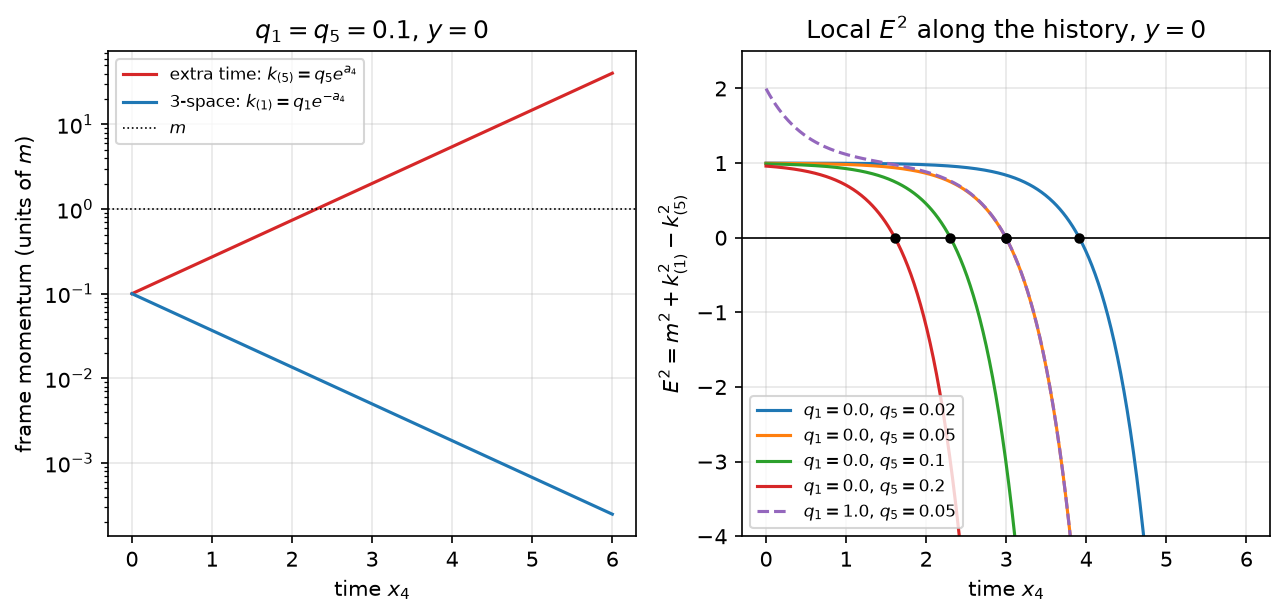

Figure 08b.2 saved as Revision/textbook/figures/08b_2_frame_momenta.png


In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
k1_path, k5_path = frame_momenta(times, 0.1, 0.1, 0.0)
left.plot(times, k5_path, color="tab:red", label="extra time: $k_{(5)} = q_5e^{a_4}$")
left.plot(times, k1_path, color="tab:blue", label="3-space: $k_{(1)} = q_1e^{-a_4}$")
left.axhline(mass, color="black", linewidth=0.8, linestyle=":", label="$m$")
left.set_yscale("log")
left.set_xlabel("time $x_4$")
left.set_ylabel("frame momentum (units of $m$)")
left.set_title("$q_1 = q_5 = 0.1$, $y = 0$")
left.legend(fontsize=8)
for q1, q5, style in ((0.0, 0.02, "-"), (0.0, 0.05, "-"), (0.0, 0.1, "-"),
                      (0.0, 0.2, "-"), (1.0, 0.05, "--")):
    right.plot(times, local_E2(times, q1, q5, 0.0), style,
               label=f"$q_1 = {q1}$, $q_5 = {q5}$")
    t_star = onset_time(q1, q5, 0.0)
    right.plot([t_star], [0.0], "o", color="black", markersize=4)
right.axhline(0.0, color="black", linewidth=0.8)
right.set_ylim(-4.0, 2.5)
right.set_xlabel("time $x_4$")
right.set_ylabel("$E^2 = m^2 + k_{(1)}^2 - k_{(5)}^2$")
right.set_title("Local $E^2$ along the history, $y = 0$")
right.legend(fontsize=8, loc="lower left");
save_figure(fig, "frame_momenta",
            "Left: the frame momenta of one wave with coordinate wave numbers "
            "$q_1 = q_5 = 0.1$ at $y = 0$ against the time $x_4$, on a logarithmic "
            "axis in units of $m$: the extra-time momentum $k_{(5)} = q_5e^{a_4}$ "
            "grows exponentially because the extra times deflate, the space "
            "momentum $k_{(1)} = q_1e^{-a_4}$ shrinks because 3-space inflates; the "
            "dotted line is the mass $m = 1$. Right: the local $E^2$ of five waves "
            "along the history; each curve crosses zero once, at its onset time "
            "(black dot), and stays negative afterwards: the wave stops oscillating "
            "and starts to grow. The dashed wave has also $q_1 = 1$: its $E^2$ "
            "starts higher, but the space term dies away like $e^{-2a_4}$ and its "
            "onset is almost that of the same wave with $q_1 = 0$.")

## 8. Every wave along an extra time reaches the onset

The onset time $x_4^\ast$ is finite for EVERY $q_5 > 0$: the formula of section 4
has $q_5$ only in a denominator inside a logarithm, so a smaller $q_5$ only delays
the onset logarithmically, and a deeper position (more negative $y$) or a nonzero
$q_1$ changes it by a bounded amount. The next cell evaluates the onset time on a
grid of $q_5$ from $10^{-4}$ to $1$, checks that it is finite and decreasing in
$q_5$, and draws it for three hidden positions and for $q_1 = 1$.

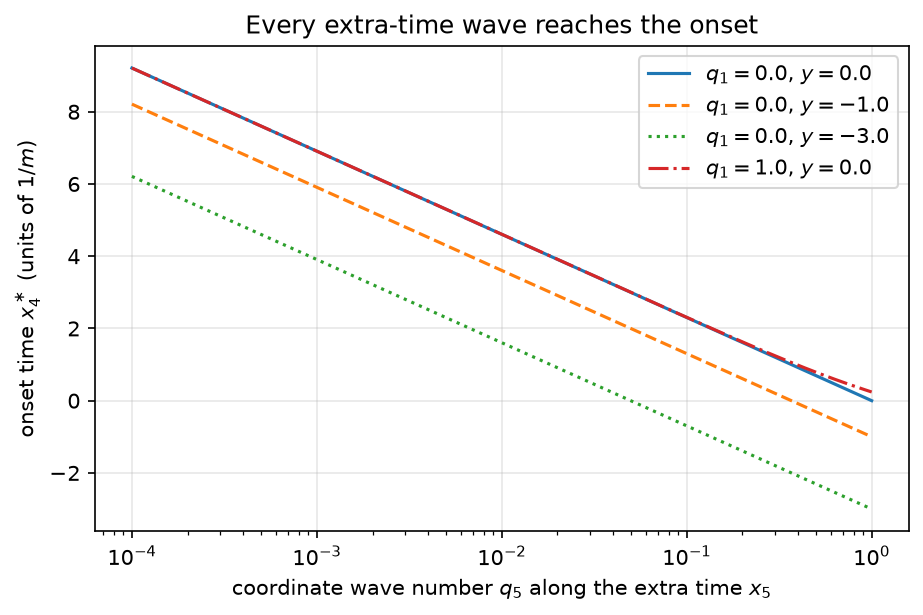

Figure 08b.3 saved as Revision/textbook/figures/08b_3_onset_times.png
PASS the onset time is finite for every q5 > 0 on the grid and decreases with q5
     reproduces Revision/theory/reports/python-field-theory.json, check
    extra_time_modes_grow


In [6]:
q5_grid = np.logspace(-4.0, 0.0, 200)  # 10^-4 ... 1, equally spaced on a log axis
fig, ax = plt.subplots()
all_finite_and_decreasing = True
for q1, y, style in ((0.0, 0.0, "-"), (0.0, -1.0, "--"), (0.0, -L_tip, ":"),
                     (1.0, 0.0, "-.")):
    onsets = onset_time(q1, q5_grid, y)
    all_finite_and_decreasing &= bool(np.all(np.isfinite(onsets))
                                      and np.all(np.diff(onsets) < 0))
    ax.plot(q5_grid, onsets, style, label=f"$q_1 = {q1}$, $y = {y}$")
ax.set_xscale("log")
ax.set_xlabel("coordinate wave number $q_5$ along the extra time $x_5$")
ax.set_ylabel("onset time $x_4^\\ast$ (units of $1/m$)")
ax.set_title("Every extra-time wave reaches the onset")
ax.legend();
save_figure(fig, "onset_times",
            "The onset time $x_4^\\ast$ at which a wave with coordinate wave number "
            "$q_5$ along the extra time $x_5$ stops oscillating and starts to grow, "
            "against $q_5$ from $10^{-4}$ to $1$ on a logarithmic axis, along the "
            "history $a_4 = x_4$ with $m = H = 1$, at the hidden positions $y = 0$ "
            "(the brane end), $y = -1$ and $y = -3$ (the tip cutoff of the "
            "Kohn-Sham record), and for a wave that also has $q_1 = 1$. Every curve "
            "is finite and rises only like $\\ln(1/q_5)$: however small $q_5$ is, "
            "the deflation of the extra times eventually drives the wave into "
            "growth; a negative onset time means that the wave grows already at "
            "$x_4 = 0$.")
check_record(all_finite_and_decreasing,
             "the onset time is finite for every q5 > 0 on the grid and decreases "
             "with q5", "Revision/theory/reports/python-field-theory.json",
             "extra_time_modes_grow",
             "every extra-time mode eventually enters the growing regime")

## 9. Following one wave through the onset: the local-frame model

The next cell reads the gamma matrices and builds the time-dependent mode matrix
$h(x_4)$ of the local-frame model. It checks at five instants, for a wave with
$q_1 = 0.3$ and $q_5 = 0.1$, that $h(x_4)^2 = E^2(x_4)\,I_{16}$, where $E^2$ is the
formula of the Revision record for frozen coefficients, $E^2 = m^2 + k_1^2 + k_2^2 +
k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2$, taken at the frame momenta of that instant
(and checks that the record holds exactly this formula). Then it chooses the
starting column for $q_1 = 0$.
With $q_1 = 0$ the matrix $C = \gamma^{(8)}\gamma^{(1)}\gamma^{(2)}\gamma^{(3)}$
commutes with $h$ ($\gamma^{(4)}$ and $\gamma^{(5)}$ each anticommute with all four
factors of $C$), so there are columns that are eigenvectors of $h(0)$ for the
positive frequency $E_0 = \sqrt{m^2 - q_5^2}$ AND of $C$ for $+1$ or $-1$. The
projectors $\Lambda_+ = (1 + h(0)/E_0)/2$ and $(1 \pm C)/2$ produce them from the
first unit column. For such a column the Krein form is $u^\dagger B u = \pm E_0/m$:
$B = -iC\gamma^{(4)} = C(-i\gamma^{(4)})$ gives $u^\dagger B u = \pm u^\dagger
(-i\gamma^{(4)})u$, and $E_0 = u^\dagger h u = m\,u^\dagger(-i\gamma^{(4)})u -
q_5\,u^\dagger\gamma^{(4)}\gamma^{(5)}u$, where the first term is real and the
second imaginary ($\gamma^{(4)}\gamma^{(5)}$ is real and antisymmetric), so the
second term vanishes. The cell checks all of this.

In [7]:
gammas_record = json.loads(
    repository_file("Revision/algebra/gammas.json").read_text(encoding="utf-8"))
GAMMA = [np.array(rows, dtype=int) for rows in gammas_record["gamma"]]
C = np.array(gammas_record["C"], dtype=int)  # C = g^(x8) g^(x1) g^(x2) g^(x3)
B = np.array(gammas_record["B"]["re"]) + 1j * np.array(gammas_record["B"]["im"])
g4 = GAMMA[3].astype(complex)  # gamma^(x4)
g4g1 = (GAMMA[3] @ GAMMA[0]).astype(complex)  # gamma^(x4) gamma^(x1)
g4g5 = (GAMMA[3] @ GAMMA[4]).astype(complex)  # gamma^(x4) gamma^(x5)
check(np.array_equal(C @ GAMMA[3], GAMMA[3] @ C) and
      np.array_equal(C @ GAMMA[4], GAMMA[4] @ C),
      "C commutes with gamma^(x4) and gamma^(x5)")


def h_local(x4, q1, q5, y):
    """The mode matrix of the local-frame model at time x4."""
    k1, k5 = frame_momenta(x4, q1, q5, y)
    return -1j * mass * g4 - k1 * g4g1 - k5 * g4g5


# At every instant h(x4)^2 = E^2(x4) I16, where E^2 is the frozen-coefficient E^2 of
# the record with k1 = k_(1)(x4), k5 = k_(5)(x4) and all other momenta 0.
m_s = sp.Symbol("m", real=True)
k_s = {a: sp.Symbol(f"k{a}", real=True) for a in (1, 2, 3, 5, 6, 7, 8)}
E2_record = m_s**2 + sum(k_s[a] ** 2 for a in (1, 2, 3, 8)) \
    - sum(k_s[a] ** 2 for a in (5, 6, 7))
squares_ok = True
for x4 in (0.0, 1.0, 2.0, 3.0, 4.0):
    k1_now, k5_now = frame_momenta(x4, 0.3, 0.1, 0.0)  # q1 = 0.3, q5 = 0.1, y = 0
    values = {symbol: 0 for symbol in k_s.values()}  # every momentum 0 ...
    values.update({m_s: mass, k_s[1]: k1_now, k_s[5]: k5_now})  # ... but these
    E2_now = float(E2_record.subs(values))
    h_now = h_local(x4, 0.3, 0.1, 0.0)
    squares_ok &= bool(np.allclose(h_now @ h_now, E2_now * np.eye(16), atol=1e-12)
                       and abs(E2_now - local_E2(x4, 0.3, 0.1, 0.0)) < 1e-12)
check_record(squares_ok, "x4 = 0, 1, 2, 3, 4: h(x4)^2 = E^2(x4) I16 (q1 = 0.3, "
             "q5 = 0.1)", "Revision/theory/reports/python-scope.json",
             "extra_time_growth_rates_unbounded", f"h_k^2 = ({sp.sstr(E2_record)}) I16")


def starting_column(q5, sign):
    """A unit column with h(0) u = E0 u and C u = sign u (q1 = 0, y = 0)."""
    h0 = h_local(0.0, 0.0, q5, 0.0)
    E0 = np.sqrt(mass**2 - q5**2)
    first = np.zeros(16, dtype=complex)
    first[0] = 1.0  # the first unit column
    u = (np.eye(16) + h0 / E0) @ ((np.eye(16) + sign * C) @ first) / 4
    return u / np.linalg.norm(u), h0, E0


starts = {}
for q5, sign in ((0.05, +1), (0.1, -1)):
    u0, h0, E0 = starting_column(q5, sign)
    starts[q5] = u0
    krein0 = np.vdot(u0, B @ u0)  # u^dagger B u
    report(f"q5 = {q5}: E0, Krein form of the start",
           f"{E0:.9f}, {krein0.real:+.9f}")
    sign_text = "+" if sign > 0 else "-"  # the sign as a character
    check(np.linalg.norm(h0 @ u0 - E0 * u0) < 1e-14 and
          np.linalg.norm(C @ u0 - sign * u0) < 1e-14 and
          abs(krein0 - sign * E0 / mass) < 1e-14,
          f"q5 = {q5}: h(0) u = E0 u, C u = {sign_text}u, "
          f"Krein form = {sign_text}E0/m")

PASS C commutes with gamma^(x4) and gamma^(x5)
PASS x4 = 0, 1, 2, 3, 4: h(x4)^2 = E^2(x4) I16 (q1 = 0.3, q5 = 0.1)
     reproduces Revision/theory/reports/python-scope.json, check
    extra_time_growth_rates_unbounded
RESULT q5 = 0.05: E0, Krein form of the start = 0.998749218, +0.998749218
PASS q5 = 0.05: h(0) u = E0 u, C u = +u, Krein form = +E0/m
RESULT q5 = 0.1: E0, Krein form of the start = 0.994987437, -0.994987437
PASS q5 = 0.1: h(0) u = E0 u, C u = -u, Krein form = -E0/m


The next cell solves $du/dx_4 = -i\,h(x_4)u$ with RK4 from $x_4 = 0$ to three
time units after the onset, for $q_5 = 0.05$ and $q_5 = 0.1$, with 12000 steps,
and records $u^\dagger u$ and $u^\dagger B u$ after every step. For $q_5 = 0.05$
it repeats the run with 6000 and 24000 steps: the differences of the end values
must shrink by a factor close to 16 (fourth order).

In [8]:
def rk4_history(u0, q5, x4_end, steps):
    """RK4 for du/dx4 = -i h(x4) u (q1 = 0, y = 0); returns the times, u^dagger u,
    u^dagger B u after every step, and the final column."""
    step = x4_end / steps
    u = u0.copy()
    times_out = [0.0]
    hilbert = [np.vdot(u, u).real]
    krein = [np.vdot(u, B @ u)]

    def rate(x4, v):  # the right-hand side -i h(x4) v
        return -1j * (h_local(x4, 0.0, q5, 0.0) @ v)

    for n in range(steps):
        x4 = n * step
        s1 = rate(x4, u)
        s2 = rate(x4 + step / 2, u + step / 2 * s1)
        s3 = rate(x4 + step / 2, u + step / 2 * s2)
        s4 = rate(x4 + step, u + step * s3)
        u = u + step / 6 * (s1 + 2 * s2 + 2 * s3 + s4)
        times_out.append((n + 1) * step)
        hilbert.append(np.vdot(u, u).real)
        krein.append(np.vdot(u, B @ u))
    return np.array(times_out), np.array(hilbert), np.array(krein), u


runs = {}
for q5 in (0.05, 0.1):
    x4_end = onset_time(0.0, q5, 0.0) + 3.0
    runs[q5] = rk4_history(starts[q5], q5, x4_end, 12000)
    final_size = runs[q5][1][-1]  # u^dagger u at the end of the run
    report(f"q5 = {q5}: ln(u^dagger u) at the onset + 3", f"{np.log(final_size):.6f}")
x4_end = onset_time(0.0, 0.05, 0.0) + 3.0
end_6000 = rk4_history(starts[0.05], 0.05, x4_end, 6000)[3]
end_24000 = rk4_history(starts[0.05], 0.05, x4_end, 24000)[3]
end_12000 = runs[0.05][3]
ratio = np.linalg.norm(end_6000 - end_12000) / np.linalg.norm(end_12000 - end_24000)
relative_error = np.linalg.norm(end_12000 - end_24000) / np.linalg.norm(end_24000)
report("RK4 error ratio (6000 vs 12000) / (12000 vs 24000) steps", f"{ratio:.2f}")
check(14.0 < ratio < 18.0, "RK4 converges with order 4 (error ratio near 16)")
check(relative_error < 1e-8, "the 12000-step run is accurate to 1e-8 (relative)")

RESULT q5 = 0.05: ln(u^dagger u) at the onset + 3 = 37.071245
RESULT q5 = 0.1: ln(u^dagger u) at the onset + 3 = 37.113916
RESULT RK4 error ratio (6000 vs 12000) / (12000 vs 24000) steps = 15.89
PASS RK4 converges with order 4 (error ratio near 16)
PASS the 12000-step run is accurate to 1e-8 (relative)


## 10. The WKB formulas and the comparison

After the onset, write $Q = k_{(5)} = q_5e^{AHx_4}$ and
$\kappa = \sqrt{Q^2 - m^2}$. Line by line:

1. Leading order: at each instant the growing eigenvalue of $-ih$ is $+\kappa$, so
   $\frac{d}{dx_4}\ln(u^\dagger u) \approx 2\kappa$ and $\ln(u^\dagger u) \approx
   2W + $ const with $W(x_4) = \int\kappa\,dx_4$.
2. Because $dQ/dx_4 = AH\,Q$, the substitution $dx_4 = dQ/(AHQ)$ gives
   $W = \frac{1}{AH}\int\frac{\sqrt{Q^2 - m^2}}{Q}dQ = \frac{1}{AH}\Big(\sqrt{Q^2 -
   m^2} - m\arccos\frac{m}{Q}\Big)$ (differentiate the bracket: $\frac{Q}{\kappa} -
   \frac{m^2}{Q\kappa} = \frac{\kappa}{Q}$).
3. First order: the matrices $A_4 = -i\gamma^{(4)}$ and $M = -i\gamma^{(4)}
   \gamma^{(5)}$ are Hermitian, square to 1 and anticommute, and $h = mA_4 - iQM$.
   In each of 8 planes spanned by a column $w$ with $A_4w = w$ and by $Mw$ the
   equation is $v' = \begin{pmatrix}-im & -Q\\ -Q & im\end{pmatrix}v$.
4. This symmetric matrix has the eigenvector $r = (Q, -\kappa - im)$ for $+\kappa$.
   Multiplying the equation by $r^T$ and keeping only the growing part $v \approx
   c\,r$ gives $c'/c = \kappa - n'/(2n)$ with $n = r^Tr = 2\kappa(\kappa + im)$.
5. Hence $|c|^2 \propto e^{2W}/|n| = e^{2W}/(2\kappa Q)$, and $u^\dagger u \approx
   |c|^2\,r^\dagger r = |c|^2\,2Q^2 \propto e^{2W}Q/\kappa$: $\ln(u^\dagger u)
   \approx 2W + \ln(Q/\kappa) + $ const, and the rate is $2\kappa + \frac{d}{dx_4}
   \ln\frac{Q}{\kappa} = 2\kappa - AH\,m^2/\kappa^2$.

Both approximations fail at the onset itself ($\kappa \to 0$), so the comparison
uses increases over a window from 1.5 to 3 time units after the onset (the
unknown constants drop out of increases). The next cell computes them.

In [9]:
def Q_of(x4, q5):
    return q5 * np.exp(a4_of(x4))  # the frame momentum k_(5) at y = 0


def kappa_of(x4, q5):
    return np.sqrt(Q_of(x4, q5) ** 2 - mass**2)


def W_of(x4, q5):
    Q = Q_of(x4, q5)
    return (np.sqrt(Q**2 - mass**2) - mass * np.arccos(mass / Q)) / (A * H)


comparison = {}
for q5 in (0.05, 0.1):
    x4s, hilbert, krein, _ = runs[q5]
    start = np.searchsorted(x4s, onset_time(0.0, q5, 0.0) + 1.5)  # window start
    xa, xb = x4s[start], x4s[-1]
    increase = np.log(hilbert[-1]) - np.log(hilbert[start])
    leading = 2 * (W_of(xb, q5) - W_of(xa, q5))
    first = leading + np.log(Q_of(xb, q5) / kappa_of(xb, q5)) \
        - np.log(Q_of(xa, q5) / kappa_of(xa, q5))
    comparison[q5] = (xa, increase, leading, first)
    say(f"q5 = {q5}: window {xa:.4f} to {xb:.4f}; increase of ln(u^dagger u) "
        f"{increase:.4f}, leading WKB {leading:.4f} (relative difference "
        f"{abs(increase - leading) / increase:.2e}), first order {first:.4f} "
        f"(relative difference {abs(increase - first) / increase:.2e})")
    check(abs(increase - leading) / increase < 2e-3,
          f"q5 = {q5}: leading WKB agrees to 2e-3 over the window")
    check(abs(increase - first) < abs(increase - leading) and
          abs(increase - first) / increase < 5e-4,
          f"q5 = {q5}: first-order WKB is better and agrees to 5e-4")
x4s, hilbert, _, _ = runs[0.05]
step = x4s[1] - x4s[0]
late_rate = (np.log(hilbert[-1]) - np.log(hilbert[-3])) / (2 * step)  # centred
kappa_late = kappa_of(x4s[-2], 0.05)  # kappa at the middle of the centred difference
predicted = 2 * kappa_late - A * H * mass**2 / kappa_late**2
report("q5 = 0.05: computed late rate, predicted 2 kappa - m^2/kappa^2",
       f"{late_rate:.5f}, {predicted:.5f}")
check(abs(late_rate - predicted) / predicted < 1e-5,
      "the late growth rate equals 2 kappa - A H m^2/kappa^2 to 1e-5")

q5 = 0.05: window 4.4958 to 5.9957; increase of ln(u^dagger u) 31.0009, leading WKB
    31.0328 (relative difference 1.03e-03), first order 31.0085 (relative difference
    2.48e-04)
PASS q5 = 0.05: leading WKB agrees to 2e-3 over the window
PASS q5 = 0.05: first-order WKB is better and agrees to 5e-4
q5 = 0.1: window 3.8028 to 5.3026; increase of ln(u^dagger u) 30.9993, leading WKB
    31.0312 (relative difference 1.03e-03), first order 31.0069 (relative difference
    2.48e-04)
PASS q5 = 0.1: leading WKB agrees to 2e-3 over the window
PASS q5 = 0.1: first-order WKB is better and agrees to 5e-4
RESULT q5 = 0.05: computed late rate, predicted 2 kappa - m^2/kappa^2 = 40.09851,
    40.09868
PASS the late growth rate equals 2 kappa - A H m^2/kappa^2 to 1e-5


The next cell draws $\ln(u^\dagger u)$ of both runs with the leading WKB curve $2W$
(shifted to agree at the window start), and the onset times.

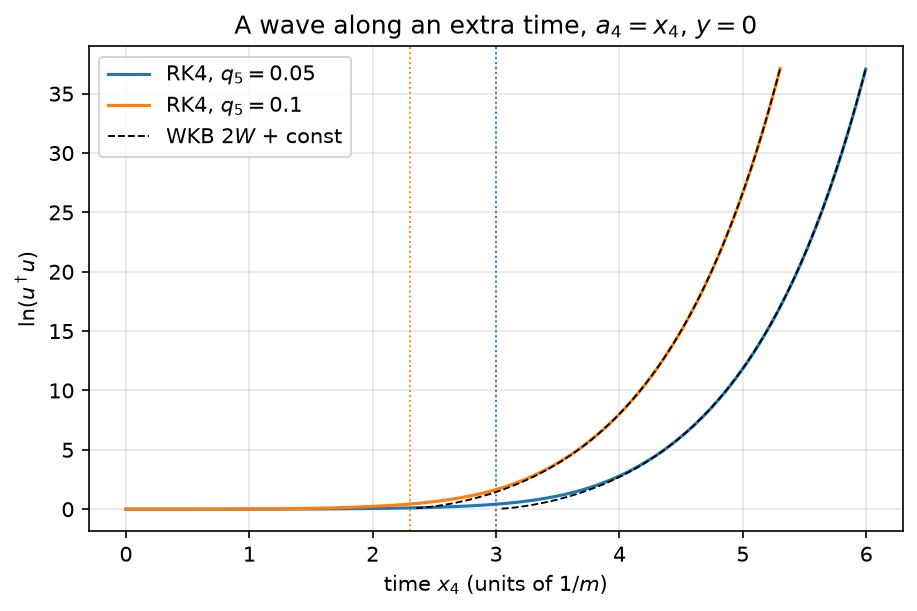

Figure 08b.4 saved as Revision/textbook/figures/08b_4_growth_along_history.png


In [10]:
fig, ax = plt.subplots()
for q5, colour in ((0.05, "tab:blue"), (0.1, "tab:orange")):
    x4s, hilbert, _, _ = runs[q5]
    xa, _, _, _ = comparison[q5]
    ax.plot(x4s, np.log(hilbert), color=colour, label=f"RK4, $q_5 = {q5}$")
    after = x4s >= onset_time(0.0, q5, 0.0) + 0.05
    shift = np.log(hilbert[np.searchsorted(x4s, xa)]) - 2 * W_of(xa, q5)
    ax.plot(x4s[after], 2 * W_of(x4s[after], q5) + shift, "--", color="black",
            linewidth=0.9)
    ax.axvline(onset_time(0.0, q5, 0.0), color=colour, linestyle=":", linewidth=0.9)
ax.plot([], [], "--", color="black", linewidth=0.9, label="WKB $2W$ + const")
ax.set_xlabel("time $x_4$ (units of $1/m$)")
ax.set_ylabel("$\\ln(u^\\dagger u)$")
ax.set_title("A wave along an extra time, $a_4 = x_4$, $y = 0$")
ax.legend();
save_figure(fig, "growth_along_history",
            "The natural logarithm of the size $u^\\dagger u$ of a wave with "
            "coordinate wave number $q_5 = 0.05$ (blue) and $q_5 = 0.1$ (orange) "
            "along the extra time $x_5$, solved with RK4 in the local-frame model "
            "along the prescribed deflating history $a_4 = x_4$ ($m = H = 1$, "
            "$y = 0$), against the time $x_4$ in units of $1/m$. Before the onset "
            "(dotted vertical lines, $x_4^\\ast = \\ln 20$ and $\\ln 10$) the wave "
            "oscillates and its size stays near 1; after the onset it grows faster "
            "and faster, by about 16 powers of ten in three time units, following "
            "the WKB curve $2W$ (black dashed, matched 1.5 units after the onset).")

The last figure shows, for $q_5 = 0.05$, the growth RATE $\frac{d}{dx_4}
\ln(u^\dagger u)$ (computed from the RK4 values by centred differences) together
with the WKB rates $2\kappa$ and $2\kappa - m^2/\kappa^2$, and the change of the
Krein form divided by $\max(u^\dagger u, 1)$. The cell checks that this change
stays below $10^{-9}$.

PASS the Krein form is conserved (drift below 1e-9)
PASS the Hilbert norm grows by more than 10^15


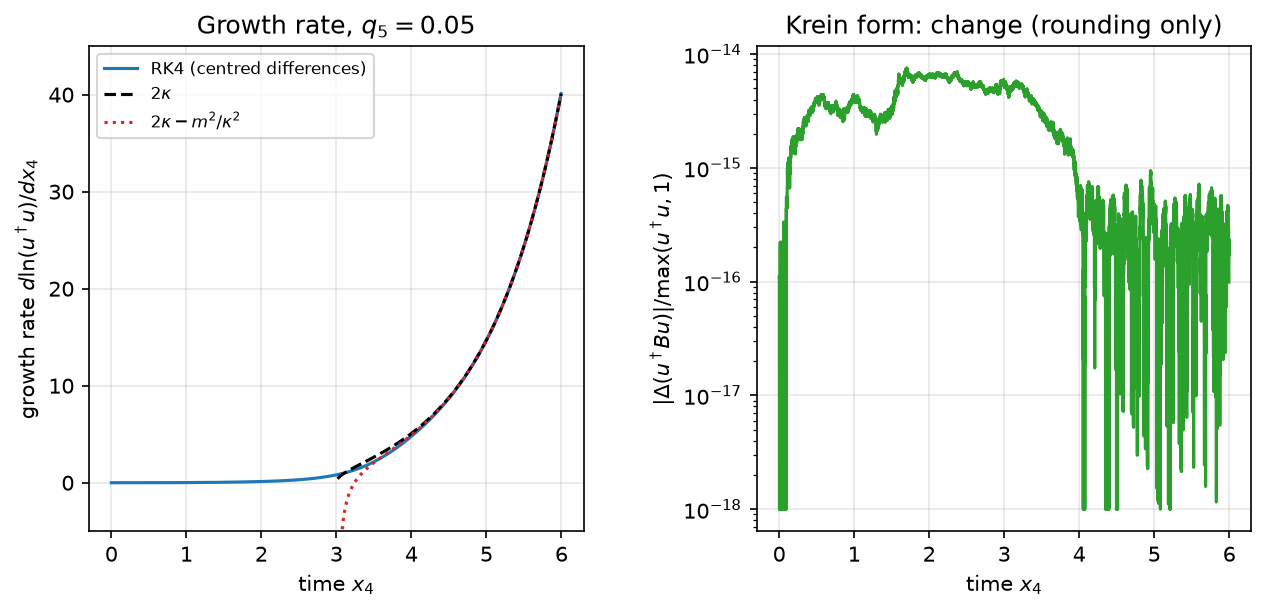

Figure 08b.5 saved as Revision/textbook/figures/08b_5_rate_and_krein.png


In [11]:
x4s, hilbert, krein, _ = runs[0.05]
step = x4s[1] - x4s[0]
computed_rate = (np.log(hilbert[2:]) - np.log(hilbert[:-2])) / (2 * step)
middle = x4s[1:-1]
after = middle > onset_time(0.0, 0.05, 0.0) + 0.02
drift = np.abs(krein - krein[0]) / np.maximum(hilbert, 1.0)
check(drift.max() < 1e-9, "the Krein form is conserved (drift below 1e-9)")
check(hilbert[-1] > 1e15, "the Hilbert norm grows by more than 10^15")

fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
fig.subplots_adjust(wspace=0.35)  # room for the label of the right panel
left.plot(middle, computed_rate, color="tab:blue", label="RK4 (centred differences)")
left.plot(middle[after], 2 * kappa_of(middle[after], 0.05), "--", color="black",
          label="$2\\kappa$")
left.plot(middle[after], 2 * kappa_of(middle[after], 0.05)
          - mass**2 / kappa_of(middle[after], 0.05) ** 2, ":", color="tab:red",
          label="$2\\kappa - m^2/\\kappa^2$")
left.set_ylim(-5.0, 45.0)
left.set_xlabel("time $x_4$")
left.set_ylabel("growth rate $d\\ln(u^\\dagger u)/dx_4$")
left.set_title("Growth rate, $q_5 = 0.05$")
left.legend(fontsize=8)
right.semilogy(x4s[1:], np.maximum(drift[1:], 1e-18), color="tab:green")
right.set_xlabel("time $x_4$")
right.set_ylabel("$|\\Delta(u^\\dagger Bu)| / \\max(u^\\dagger u, 1)$")
right.set_title("Krein form: change (rounding only)")
save_figure(fig, "rate_and_krein",
            "Left: the growth rate $d\\ln(u^\\dagger u)/dx_4$ of the wave with "
            "$q_5 = 0.05$ against the time $x_4$ (units of $1/m$ and $m$), computed "
            "from the RK4 solution (blue), with the leading WKB rate $2\\kappa$ "
            "(black dashed) and the first-order rate $2\\kappa - m^2/\\kappa^2$ "
            "(red dotted); before the onset the rate stays near zero, after it the "
            "rate itself grows exponentially, so the growth is faster than any "
            "exponential, and far from the onset the first-order rate is accurate. "
            "Right: the change of the Krein form $u^\\dagger Bu$ divided by "
            "$\\max(u^\\dagger u, 1)$, on a logarithmic axis (exact zeros are drawn "
            "at $10^{-18}$); it stays at the level of rounding errors, far below "
            "$10^{-9}$.")

## 11. The last check

The last cell checks that the five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [12]:
for name in ("08b_1_scale_factors.png", "08b_2_frame_momenta.png",
             "08b_3_onset_times.png", "08b_4_growth_along_history.png",
             "08b_5_rate_and_krein.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 08b_1_scale_factors.png exists
PASS the figure file 08b_2_frame_momenta.png exists
PASS the figure file 08b_3_onset_times.png exists
PASS the figure file 08b_4_growth_along_history.png exists
PASS the figure file 08b_5_rate_and_krein.png exists
ALL 25 CHECKS PASSED (notebook 08b)


## 12. What this notebook showed

- Along the prescribed deflating history $a_4 = AHx_4$ of the Kohn-Sham record
  ($A = H = m = 1$) 3-space inflates like $e^{a_4}$ and the extra times deflate like
  $e^{-a_4}$, while the volume factor $\sqrt{|g|} = \cos z$ stays constant (PROVED,
  exact sympy; Revision check `sqrt_det_g_equals_cos_z`).
- A wave $e^{i(q_1x_1 + q_5x_5)}$ keeps its coordinate wave numbers; its frame
  momentum along the extra time grows like $q_5e^{a_4}e^{-Hy}$ and along 3-space it
  shrinks like $q_1e^{-a_4}e^{-Hy}$ (PROVED).
- With frozen coefficients its $E^2$ turns negative at the onset time
  $x_4^\ast = \ln(X^\ast)/(2AH)$, finite for every $q_5 > 0$: every wave along an
  extra time eventually enters the growing regime (PROVED for the frozen
  coefficients; the Revision statement `extra_time_modes_grow` is this local-frame
  statement).
- In the local-frame model (MODEL: hidden position frozen; not an exact solution of
  the field equation) a wave started with positive frequency oscillates until the
  onset and then grows faster than any exponential, by about $10^{16}$ in three
  time units; the growth follows the WKB formulas (COMPUTED: leading order to about
  $10^{-3}$, first order to about $2.5 \times 10^{-4}$ over the window, late rate to
  $10^{-5}$), and the Krein form is conserved to rounding.
- Consequence (with Notebook 08a): for data that depend on the extra times the
  initial-value problem is not well posed, and the deflation makes every such wave
  reach the growing regime. Only the good sector (no dependence on $x_5, x_6, x_7$)
  is free of this growth; restricting to it is a choice, not a result.